In [1]:
import matplotlib.pyplot as plt  # 导入 matplotlib 库，用于图像显示
from PIL import Image  # 导入 PIL 库，用于图像加载和处理
import torchvision.transforms as transforms  # 导入 torchvision.transforms 模块，用于图像预处理

自编码器

In [2]:
# 加载 JPG 图像
img_path = 'Apple.jpg'  # 图像文件路径，替换为你的图像路径
image = Image.open(img_path)  # 使用 PIL 打开图像

In [3]:
# 定义图像转换操作
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # 调整图像大小为 256x256
    transforms.ToTensor(),  # 将图像转换为 PyTorch 张量
])

In [4]:
# 应用定义的转换操作
img_tensor = transform(image)  # 将图像转换为张量并调整大小
print(img_tensor)
print(img_tensor.shape)  # 打印张量的形状，格式为 (C, H, W)

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])
torch.Size([3, 256, 256])


In [5]:
# 将张量转换为 NumPy 数组
img_numpy = img_tensor.numpy()  # 将 PyTorch 张量转换为 NumPy 数组，形状为 (C, H, W)
print(img_numpy.shape)

(3, 256, 256)


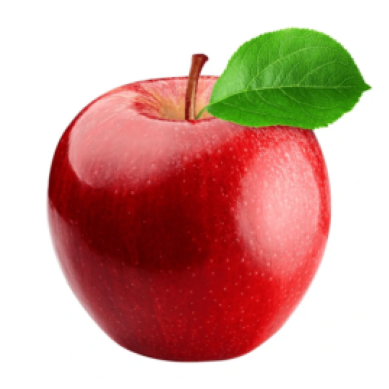

In [6]:
# PoTorch 的图像张量使用 (C, H, W) 格式，而 Matplotlib 的图像显示函数需要 (H, W, C) 格式的数组，需要转换维度
# 调整 NumPy 数组的维度顺序
img_numpy = img_numpy.transpose((1, 2, 0))  # 将形状从 (C, H, W) 转换为 (H, W, C)

# 显示图像
plt.imshow(img_numpy)  # 显示调整后的 NumPy 数组
plt.axis('off')  # 不显示坐标轴
plt.show()  # 显示图像

In [7]:
import torch  # 导入 PyTorch 库
import torch.nn as nn  # 导入 PyTorch 的神经网络模块
import torch.optim as optim  # 导入 PyTorch 的优化器模块


# 定义自编码器（Autoencoder）的架构
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()  # 调用父类的构造函数，初始化模型

        # 编码器部分：将输入图像压缩为低维特征表示
        self.encoder = nn.Sequential(
            # 第一层卷积：输入通道数为 3（RGB 图像），输出通道数为 16，卷积核大小为 3x3，步长为 1，填充为 1
            # 输出尺寸：(16, 256, 256)
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),  # ReLU 激活函数，引入非线性
            # 最大池化层：池化核大小为 2x2，步长为 2，将图像尺寸减半
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 第二层卷积：输入通道数为 16，输出通道数为 8，卷积核大小为 3x3，步长为 1，填充为 1
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),  # ReLU 激活函数
            # 最大池化层：池化核大小为 2x2，步长为 2，将图像尺寸再次减半
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 解码器部分：将低维特征表示重构为原始图像
        self.decoder = nn.Sequential(
            # 第一层转置卷积：输入通道数为 8，输出通道数为 16，卷积核大小为 3x3，步长为 2，填充为 1，输出填充为 1
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),  # ReLU 激活函数
            # 第二层转置卷积：输入通道数为 16，输出通道数为 3，卷积核大小为 3x3，步长为 2，填充为 1，输出填充为 1
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Sigmoid 激活函数，将输出值限制在 [0, 1] 范围内，表示像素值
        )

    def forward(self, x):
        encode = self.encoder(x)  # 对输入图像进行编码
        decode = self.decoder(encode)  # 对编码后的特征进行解码，重构图像
        # print("encode shape: ", encode.shape)
        # print("decode shape: ", decode.shape)
        return decode

In [8]:
# 初始化自编码器模型
model = Autoencoder()

# 测试模型前向传播
x = model.forward(torch.randn(1, 3, 256, 256))

In [9]:
# 将模型移动到 GPU（如果可用），否则使用 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # 打印当前使用的设备（GPU 或 CPU）
model.to(device)  # 将模型参数和缓冲区移动到指定设备

cuda


Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [10]:
# 定义损失函数和优化器
criterion = nn.MSELoss()  # 使用均方误差损失（MSE），衡量重构图像与原始图像的差异
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 使用 Adam 优化器，学习率为 0.001

In [11]:
# 训练自编码器
num_epochs = 400  # 训练的总轮数
for epoch in range(num_epochs):
    img = img_tensor.to(device)  # 将输入图像移动到指定设备
    output = model(img)  # 前向传播，获取重构图像
    loss = criterion(output, img)  # 计算损失（重构图像与原始图像的差异）
    loss.backward()  # 反向传播，计算梯度
    optimizer.step()  # 更新模型参数
    optimizer.zero_grad()  # 清空梯度缓存，避免梯度累积
    if (epoch + 1) % 50 == 0:  # 每 50 轮打印 一次损失值
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/400], Loss: 0.0851
Epoch [100/400], Loss: 0.0428
Epoch [150/400], Loss: 0.0223
Epoch [200/400], Loss: 0.0133
Epoch [250/400], Loss: 0.0097
Epoch [300/400], Loss: 0.0078
Epoch [350/400], Loss: 0.0061
Epoch [400/400], Loss: 0.0045


In [12]:
# 保存训练好的模型
torch.save(model.state_dict(), 'conv_autoencoder.pth')

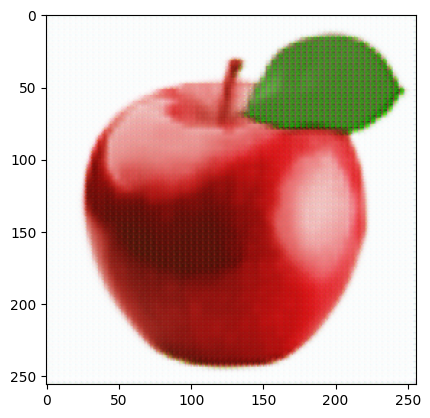

In [13]:
# 推理阶段不需要梯度计算
# 禁用梯度计算，减少内存消耗并加速推理过程
with torch.no_grad():
    # 将图像张量移动到指定设备（GPU 或 CPU）
    data = img_tensor.to(device)
    # 使用训练好的模型对输入数据进行重构，得到输出张量
    recon = model(data)
# 显示重构后的图像
# 1. 将张量从 GPU 移到 CPU（如果张量在 GPU 上）
# 2. 转换为 NumPy 数组
# 3. 调整维度顺序从 (C, H, W) 到 (H, W, C)，以适配 Matplotlib 的 imshow 函数
plt.imshow(recon.cpu().numpy().transpose((1, 2, 0)))
plt.show()

In [14]:
img_noise = img_tensor + torch.randn_like(img_tensor) * 0.5

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8919945..3.0818334].


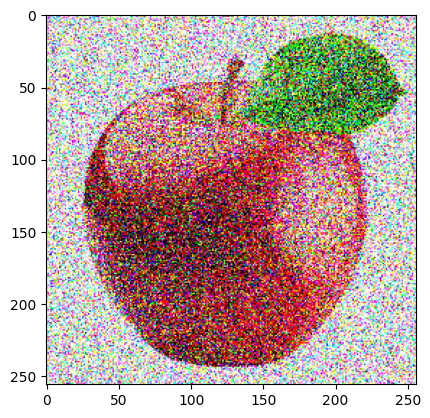

In [15]:
img_numpy = img_noise.permute(1, 2, 0).numpy()
plt.imshow(img_numpy)
plt.show()

In [16]:
# 训练自编码器
for epoch in range(num_epochs):
    img = img_noise.to(device)  # 将输入图像移动到指定设备
    target = img_tensor.to(device)
    output = model(img)  # 前向传播，获取重构图像
    loss = criterion(output, target)  # 计算损失（重构图像与原始图像的差异）
    loss.backward()  # 反向传播，计算梯度
    optimizer.step()  # 更新模型参数
    optimizer.zero_grad()  # 清空梯度缓存，避免梯度累积
    if (epoch + 1) % 50 == 0:  # 每 50 轮打印 一次损失值
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/400], Loss: 0.0059
Epoch [100/400], Loss: 0.0051
Epoch [150/400], Loss: 0.0048
Epoch [200/400], Loss: 0.0045
Epoch [250/400], Loss: 0.0043
Epoch [300/400], Loss: 0.0041
Epoch [350/400], Loss: 0.0040
Epoch [400/400], Loss: 0.0039


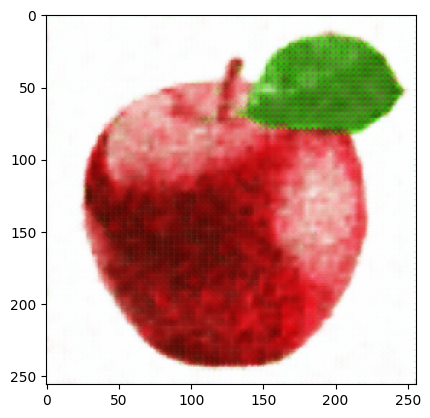

In [17]:
# 推理阶段不需要梯度计算
# 禁用梯度计算，减少内存消耗并加速推理过程
with torch.no_grad():
    # 将图像张量移动到指定设备（GPU 或 CPU）
    data = img_noise.to(device)
    # 使用训练好的模型对输入数据进行重构，得到输出张量
    recon = model(data)
# 显示重构后的图像
# 1. 将张量从 GPU 移到 CPU（如果张量在 GPU 上）
# 2. 转换为 NumPy 数组
# 3. 调整维度顺序从 (C, H, W) 到 (H, W, C)，以适配 Matplotlib 的 imshow 函数
plt.imshow(recon.cpu().numpy().transpose((1, 2, 0)))
plt.show()